In [1]:
import numpy
import scipy
from os.path import join
import matplotlib.pyplot as plt
import matplotlib
import texplot
import matplotlib.ticker as mticker

import freealg
from freealg import AlgebraicForm
from freealg.distributions import MarchenkoPastur, ChiralBlock, CompoundFreePoisson, FreeLevy
from freealg.visualization import plot_flow, plot_mass, ridgeplot, plot_edges
from freealg.visualization._api_plot_util import _k_pow2_formatter

plot_dir = './plots'
save_filename = 'cfp'
title = 'Compound Free Poisson'
latex = True

# Compound Free Poisson

[(0.9984996249062267, 3.13165791447862), (4.157389347336835, 7.597674418604652)]


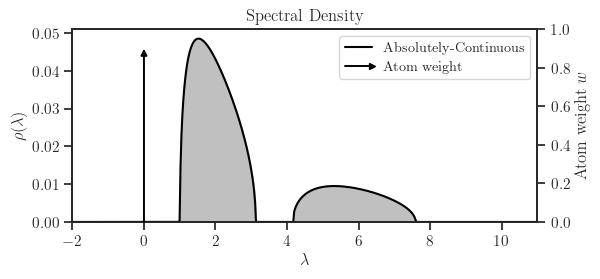

In [2]:
lam = 0.1
t1 = 2.0
t2 = 5.5
w1 = 0.75

dist = CompoundFreePoisson(t=[t1, t2], w=[w1, 1-w1], lam=lam)
# dist = FreeLevy(t=[t1, t2], w=[w1, 1-w1], lam=lam, a=0.0, sigma=0.2)

# Support
support = dist.support()
print(support)

# Grid
x_min = numpy.floor(min(a for a, b in support) - 1.0)
x_max = numpy.ceil(max(b for a, b in support) + 1.0)
y_min, y_max = -3.0, 3.0

_ = dist.density(plot=True, latex=True, save=False)

# Submatrix

In [7]:
# # Create data if not exists
# A = dist.matrix(8000, seed=0)
# eig_A = numpy.linalg.eigvalsh(A)

# As = freealg.submatrix(A, 1000, seed=0)
# eig_As = numpy.linalg.eigvalsh(As)

# out = {
#     'eig_A': eig_A,
#     'eig_As': eig_As,
#     'lam': lam,
#     't': [t1, t2],
#     'w1': w1,
#     'n': A.shape[0],
#     'n0': As.shape[0]
# }

# filename = 'free-levy.npz'
# dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
# out_filename = join(dir_, filename)
# numpy.savez(out_filename, out=numpy.array(out, dtype=object))

In [3]:
# # Load data if already created before
# filename = 'free-levy.npz'
# dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
# out_filename = join(dir_, filename)

# data = numpy.load(out_filename, allow_pickle=True)
# out = data['out'].item()

# eig_A = out['eig_A']
# eig_As = out['eig_As']
# n = out['n']
# n0 = out['n0']

# Submatrices

Idx   Size   Repeat
---  -----   ------
0     1000       16
1     1414       11
2     2000        8
3     2828        5
4     4000        4
5     5656        2
6     8000        2
7    11313        1
8    16000        1
9    22627        1
10   32000        1

proc name: Intel(R) Xeon(R) Gold 6126 CPU @ 2.60GHz
num proc:  48
date:      2026-04-16 01:45:40 PDT



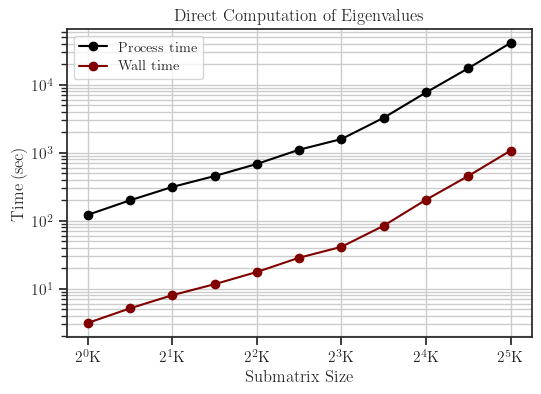

In [3]:
# Load input file
# filename = 'cfp_32K_eigs.npz'
filename = 'cfp_32K_eigs_half.npz'
# filename = 'cfp_64K_eigs_half.npz'

dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
data = numpy.load(join(dir_, filename), allow_pickle=True)
out = data['out'].item()

# Extract variables
sizes = out['sizes']                 # List of sizes of the submatrices
repeats = out['repeats']             # Repeats of sampling
eigs_repeated = out['eigs']          # List of eigenvalues per each submatrix
eigs = out['eigs']                   # List of eigenvalues per each submatrix
wall_times = out['wall_times']       # List of wall times taken to compute eigenvalues
proc_times = out['proc_times']       # List of CPU process times taken to compute eigenvalues
n, p = out['shape']                  # Dimension of the original matrix (largest matrix)
proc_name = out['proc_name']
num_proc = out['num_proc']
date = out['date']

# concatenate all repeats
max_repeat = 1
eigs = [None] * len(eigs_repeated)
for i in range(len(eigs_repeated)):
    rep_size = min(eigs_repeated[i].shape[0], max_repeat)
    eigs[i] = eigs_repeated[i][:rep_size, :].ravel()

# Sizes of submatrices
print('Idx   Size   Repeat')
print('---  -----   ------')
for i in range(sizes.size):
    print(f'{i:<2d}  {sizes[i]:>6d}  {repeats[i]:>7d}')
print('')
print(f'proc name: {proc_name}')
print(f'num proc:  {num_proc}')
print(f'date:      {date}')
print('')

# Plot wall and process times
with texplot.theme(use_latex=latex):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(sizes, proc_times, '-o', color='black', label='Process time')
    ax.plot(sizes, wall_times, '-o', color='maroon', label='Wall time')
    ax.set_xlabel('Submatrix Size')
    ax.set_ylabel('Time (sec)')
    ax.set_title('Direct Computation of Eigenvalues')
    ax.legend(fontsize='small')
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_locator(mticker.LogLocator(base=2, subs=(1000/512.0,)))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(_k_pow2_formatter))
    ax.set_yscale('log')
    ax.grid(True, which='both')
    plt.show()

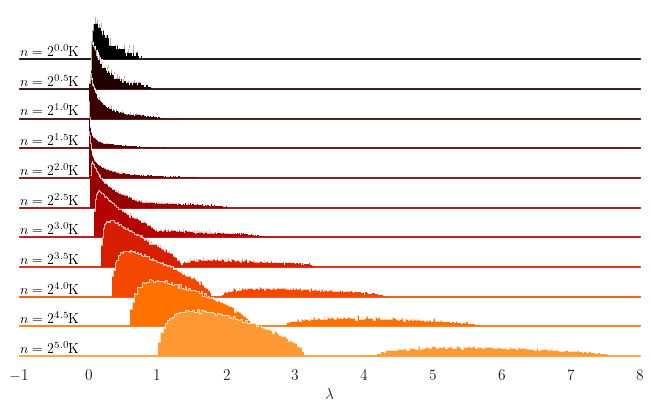

In [117]:
eigs_no_atom = [None] * len(eigs)
tol = 1e-4
for i in range(len(eigs)):
    eigs_no_atom[i] = eigs[i][numpy.abs(eigs[i]) > tol]

ridgeplot(sizes, eigs=eigs_no_atom, log=False, scaley=True, hspace=-0.4,
          text_side='left', xlim=(-1, 8), ylim=None, figsize=(8, 4.5),
          # label_mode='pow-int',
          label_mode='pow-dec',
          latex=latex, title='',
          save=False, nbins=200)

# Fit Spectral Curve


------------------------------------------
Support (detected from histogram):
| bulk 1 | interval: ( -0.00000,   1.61833) | center:   0.80916 |  mass: 100.00% |
mass(x) ~ 0.5 + 0.6179 * x

------------------------------------------
fit residual max  : 1.8161e-04
fit residual 99.9%: 1.8145e-04

Coefficients (real)
+1.00000000 +0.64861553 +0.03432480 -0.00000222 
+0.00000000 +1.00000000 +0.93595930 +0.17132923 

Coefficients (imag) norm: 0.0000e+00


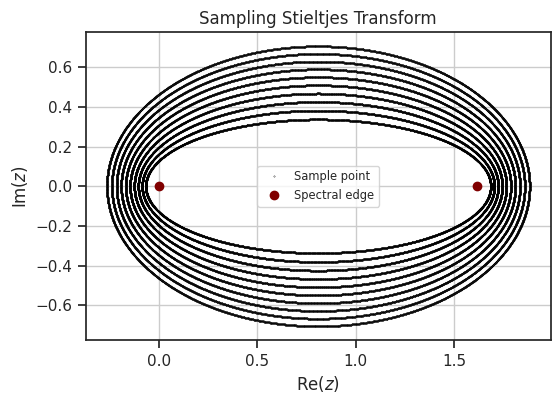


------------------------------------------
Atoms (estimated from polynomial):
	Atom 1. x: 1.3e-05, weight: 20.0%

------------------------------------------
is decompressible: True


In [4]:
# Index to choose the initial sub-matrix size
# start_idx = 2  # TEST
start_idx = 4

# Detect support from histogram
print('\n------------------------------------------')
print('Support (detected from histogram):')
support = freealg.supp(eigs[start_idx], method='hist', tol=0, nbins=150, log=False,
                      print_info=True)

# Stieltjes options
stieltjes_opt = dict(
    n_levels = 200,
    max_subdivide = 20,
    anchor_mode = 'empirical',   # empirical, asymptotic
    anchor_y_min = 1e-4,  # 1e-5~1e-6 cause left bulks to fail
    anchor_y_max = 1,
    anchor_ratio = 0.01,  # 0.1~1 cause stieltjes_emp to not latch to poly roots
    # anchor_match_tol = numpy.inf,  # disables anchor retry
    # anchor_ratio_tol = numpy.inf,
    anchor_match_tol = 0.1,       # retry if init anchor not mathc roots
    anchor_ratio_tol = 0.9,
    anchor_retry_factor = 3.0     # factor to multiple anchor height in retrial
)

# Inverse Stieltjes options
inv_stieltjes_opt = dict(
    delta = 1e-6,
    delta_ladder_ratio = 2.0,
    delta_ladder_size = 4,
    delta_ladder_grid = 'linear',   # geometric, linear
    z_query_delta = 'const',       # const, linear
    method = 'chebfit',             # direct, polyfit, chebfit, poisson
    fit_degree = 2,
    reg = 0.0,
    fit_weight = 'uniform',  # 'uniform, small_delta
)

# af = AlgebraicForm(dist)
af = AlgebraicForm(eigs[start_idx],
                   # support=None,
                   support=support,
                   n=sizes[start_idx],
                   log=False,
                   dtype='complex128',
                   stieltjes_opt=stieltjes_opt,
                   inv_stieltjes_opt=inv_stieltjes_opt)

print('\n------------------------------------------')
deg_m, deg_z = 3, 1

# coeffs = af.fit(
#     deg_m, deg_z, reg=0, normalize=True, triangular=(None, None),
#     mu=None, mu_reg=None, verbose=True)

deg_mu = 0
mu = numpy.zeros((deg_mu+1, ), dtype=float)
mu[0] = 1.0
for i in range(1, mu.size):
    if i == 1:
        mu[i] = numpy.mean(af.eig)
    else:
        mu[i] = numpy.mean(af.eig**i)

coeffs = af.fit(
    deg_m, deg_z,
    reg=0,
    # r_min=1.8, r_max=2.2, n_r=5,
    r_min=1.5, r_max=2.2, n_r=10,
    y_scale=1.0, gamma=1.0,
    n_samples=4096,
    cut_eps=0.01,
    normalize=True,
    triangular=(None, None),
    mu=mu,
    mu_reg=None, verbose=True, plot=True)

# print('\n------------------------------------------')
# print('Support (estimated from polynomial):')
# est_supp = af.support()
# for i, supp in enumerate(est_supp):
#     print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

print('\n------------------------------------------')
print('Atoms (estimated from polynomial):')
for i, atom in enumerate(af.atoms()):
    print(f'\tAtom {i+1}. x: {atom[0]:>4.1e}, weight: {100.0*atom[1]:>4.1f}%')

print('\n------------------------------------------')
status = af.is_decompressible()
print(f'is decompressible: {status}')

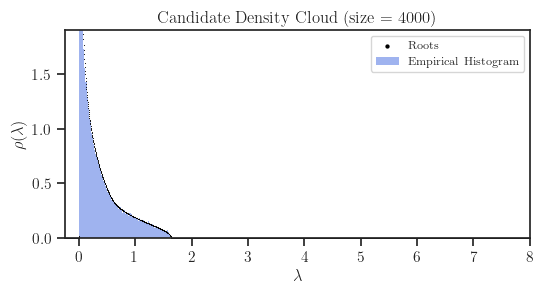

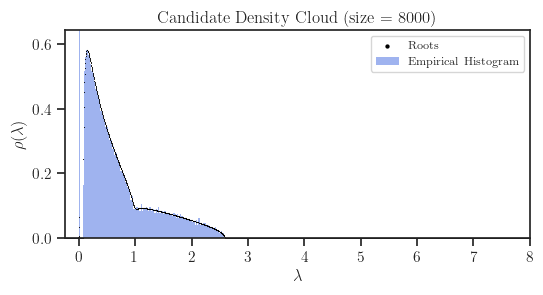

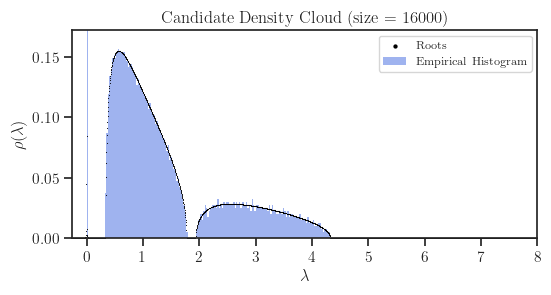

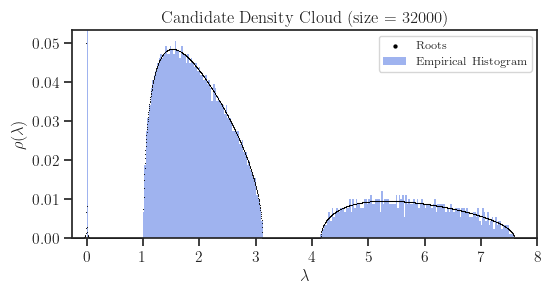

In [119]:
# Check if the density plotted above is formed by correct roots. For this,
# we plot all possible roots below.
x_min = -0.25
x_max = 8
x_highres = numpy.linspace(x_min, x_max, 2000)

# for idx in [start_idx, start_idx+1, sizes.size-1]:
for idx in range(start_idx, sizes.size, 2):
    # ylim = (0, 0.06) if idx == sizes.size - 1 else None
    e = eigs[idx]
    h = numpy.histogram(e, 100, density=True)[0]
    ylim = (0, 1.1 * float(numpy.max(h[5:])))
    af.candidates(
        size=sizes[idx],
        x=x_highres,
        eig=eigs[idx],
        delta=None, markersize=0.6,
        ylim=ylim, latex=latex)

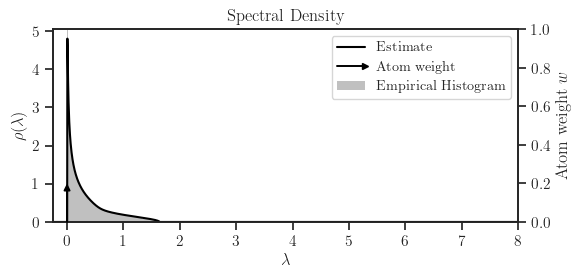


------------------------------------------
Mass: 0.79916264


In [120]:
x0 = numpy.linspace(x_min, x_max, 2000)
rho0 = af.density(x0, plot=True, latex=latex)

# Check mass (at start size)
print('\n------------------------------------------')
mass = numpy.trapz(rho0, x0)
print(f'Mass: {mass:0.8f}')

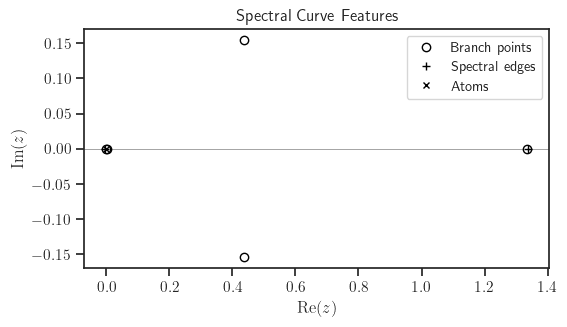


i   Branch Points        Spectral Edge
--  -------------------  -------------
1    +1.3359+0.000e+00i  Maybe
2    +0.4364+1.543e-01i  No
3    +0.4364-1.543e-01i  No
4    +0.0008+0.000e+00i  Maybe
5    -0.0000+0.000e+00i  Maybe


In [92]:
# Branch points
bp = af.branch_points(tol=1e-16, real_tol=1e-16, plot=True, latex=latex)

# A branch point on real axis is a candidate to also be a spectral edge.
# Those with near zero imaginary part are flagged as maybe a spectral edge.
print('\ni   Branch Points        Spectral Edge')
print('--  -------------------  -------------')
for i in range(bp.size):
    print(f'{i+1}   {bp[i].real:>+8.4f}{bp[i].imag:>+5.3e}i', end='  ')
    if numpy.abs(bp[i].imag) < 1e-14:
        print('Maybe')
    else:
        print('No')

# Free Decompression

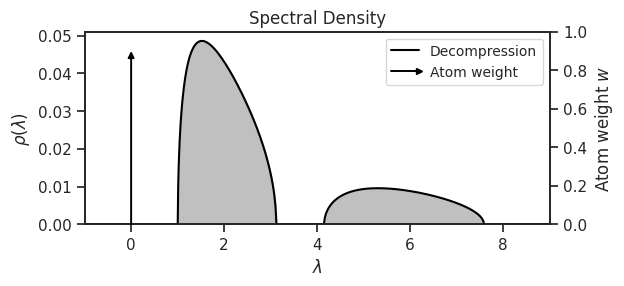

In [5]:
# Choosing the largest sub-matrix size to decompress to
end_idx = sizes.size - 1

# Subset of sizes to apply free decompression
fd_sizes = sizes[start_idx:end_idx+1]

x = numpy.linspace(x_min, x_max, 1000)
# fd_sizes = numpy.arange(As.shape[0], A.shape[0]+1, 500)
# base = 1000
# fd_sizes = base * 2**(numpy.arange(numpy.log2(As.shape[0]/base),
#                                    numpy.log2(A.shape[0]/base)+0.01, 0.5))

newton_opt = dict(
    dt_max=0.001,
    dt_min=1e-10,
    tol=1e-14,
    max_iter=1000,
    parallel=True,
    n_jobs=8,
    log_mode=False,
    pair_enable=True,
    pair_gap_factor=10.0,
)

rho, x, atoms = af.decompress(
    fd_sizes, x=x, method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=True,
    atom_eps=1e-2,
    verbose=False, plot=True, latex=False)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/cfp-flow.pdf".


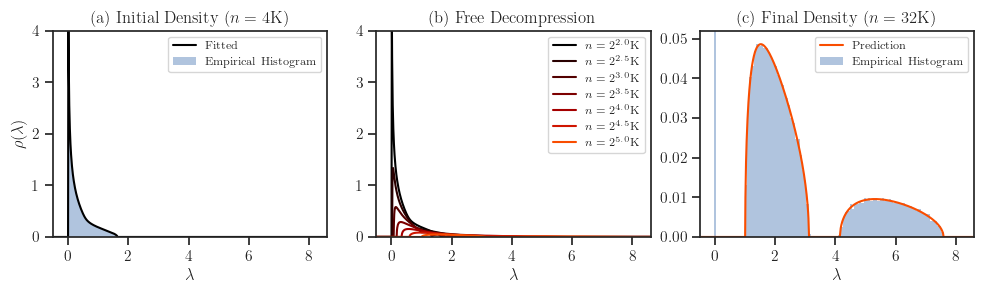

In [7]:
plot_flow(fd_sizes, x, rho, eigs[start_idx], eigs[end_idx], delta=af.delta,
          figsize=None,
          xlim=[-0.5, 8.6],
          ylim=[(0, 4), (0, 4), (0, 0.052)], share_ax=False, layout='horizontal',
          title='Free Decompression',
          cmap=plt.cm.gist_heat,
          c_range=(0.0, 0.65),
          hist_color='lightsteelblue',
          nbins=(60, 100),
          label_mode='pow-dec',
          inset_ax=None, inset_pos=None, inset_lims=None,
          save=join(plot_dir, save_filename + '-flow.pdf'),
          latex=latex)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/cfp-ridge.pdf".


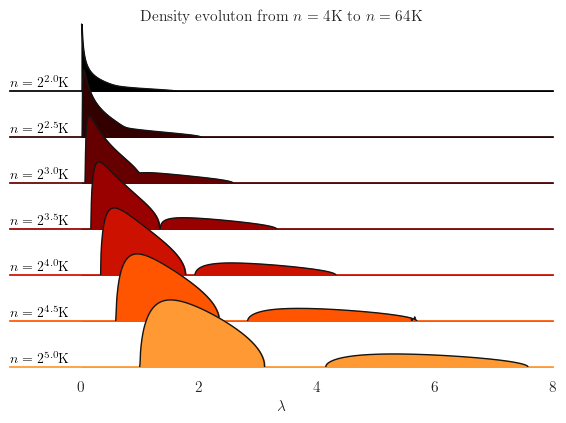

In [126]:
# eigs_no_atom = [None] * len(eigs)
# tol = 1e-4
# for i in range(len(eigs)):
#     eigs_no_atom[i] = eigs[i][numpy.abs(eigs[i]) > tol]

# Set zero density to be slihtly below axis to show background axis
rho_ = numpy.copy(rho)
rho_[rho_ < 1e-14] = -1e-3

mask = x > 0.01
gray = 0.08
ridgeplot(fd_sizes, x=x[mask], rho=rho_[:, mask],
          # eigs=eigs[start_idx:end_idx+1],
          eigs=None,
          log=False, ylim=None, scaley=True, hspace=-0.35,
          cmap=plt.cm.gist_heat, c_range=(0, 0.8),
          rho_color=(gray, gray, gray),
          text_side='left', xlim=(-1.2, 8.0), figsize=(7, 4.5),
          # label_mode='pow-int',
          label_mode='pow-dec',
          latex=latex, nbins=395,
          title=r'Density evoluton from $n=4$K to $n=64$K',
          save=join(plot_dir, save_filename + '-ridge.pdf'))

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/cfp-mass.pdf".


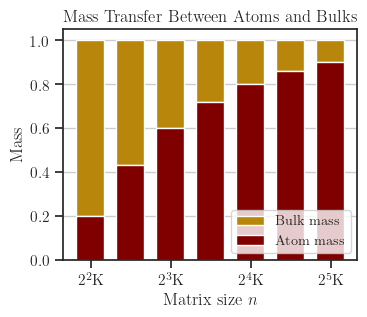

In [7]:
x0 = numpy.linspace(x_min, x_max, 3000)
rho0 = af.density(x0)

plot_mass(fd_sizes, x, rho, x0=x0, rho0=rho0, atoms=atoms, gap=0.7, latex=latex,
          figsize=(3.8, 3),
          log_x=True,
          save=join(plot_dir, save_filename + '-mass.pdf'))

# Edge and Cusp

In [8]:
# fd_sizes = numpy.arange(As.shape[0], A.shape[0]+1, 500)
# base = 1000
# fd_sizes = base * 2**(numpy.arange(numpy.log2(As.shape[0]/base),
#                                    numpy.log2(A.shape[0]/base)+0.01, 0.5))
# start_idx = 0
# end_idx = fd_sizes.size - 1

end_idx = sizes.size - 1
fd_sizes = sizes[start_idx:end_idx+1]

t_final = numpy.log(fd_sizes[-1] / fd_sizes[0])
t = numpy.linspace(0, t_final, 1000)

# cusps, info = af.cusp(t, max_iter=200, tol=1e-8, dedup_t_tol=1e-6, dedup_x_tol=1e-6,
#                       return_info=True)

complex_edges, real_merged_edges, active_k, cusps = af.edge(
    t, supp=support, dt_max=0.01, max_iter=100, tol=1e-12)

print('Cusps:')
if len(cusps) > 0:
    for cusp in cusps:
        print(f'\tx: {cusp[0]:>0.3f}, t: {cusp[1]:>0.3f}')

Cusps:
	x: 1.236, t: 0.949


Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/cfp-edge.pdf".


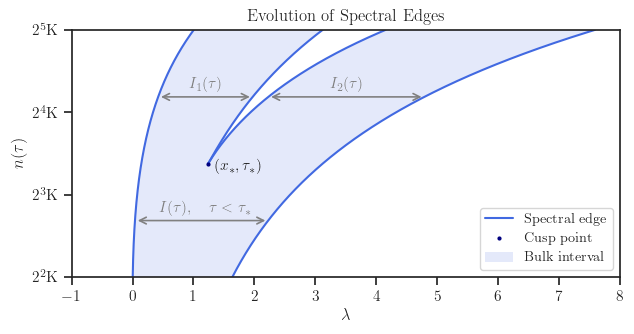

In [9]:
plot_edges(t, complex_edges, real_merged_edges, cusps=cusps, sizes=fd_sizes,
           # sizes=None,
           edge_color='royalblue', fill_color='royalblue', alpha=0.14,
           figsize=None, annotate=True, xlim=(-1, 8), log_x=False, log_y=True,
           flip_y=False,
           save=join(plot_dir, save_filename + '-edge.pdf'), latex=latex)

# Edge and Histogram

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/algebraic-compound-poisson-edge-hist.pdf".


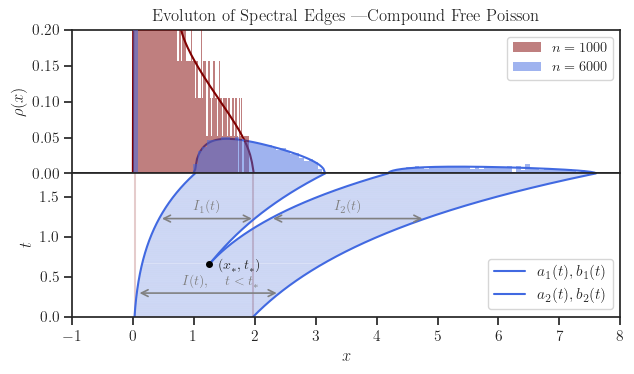

In [81]:
# k = len(support)
k = real_merged_edges.shape[1] // 2

# colors = ['royalblue', 'maroon']
colors = ['royalblue', 'royalblue']

with texplot.theme(use_latex=True):
    
    fig, ax = plt.subplots(figsize=(6.5, 3.9), nrows=2, sharex=True) 

    # Histogram
    ax[0].hist(eig_As, 100, density=True, zorder=10, alpha=0.5, color='maroon',
               edgecolor='none', label=rf'$n = {{{fd_sizes[0]}}}$')
    ax[0].hist(eig_A, 100, density=True, zorder=10, alpha=0.5, color='royalblue',
               edgecolor='none', label=rf'$n = {{{fd_sizes[-1]}}}$')
    
    ax[0].set_xlim([x[0], x[-1]])
    # ax[0].set_ylim(bottom=0)
    ax[0].set_ylim([0, 0.2])
    # ax[0].set_xlabel(r'$x$')
    ax[0].set_ylabel(r'$\rho(x)$')
    ax[0].set_title(r'Evoluton of Spectral Edges |' + title)
    ax[0].legend(fontsize='small')
    # ax[0].tick_params(labelbottom=False)
    ax[0].tick_params(axis='x', bottom=False, labelbottom=False)

    # rho
    # num_plots = rho.shape[0]
    # cmap = plt.get_cmap('gist_heat')
    # colors = [cmap(i/(num_plots + 2)) for i in range(num_plots + 1)][1:]
    ax[0].plot(x, rho[0], color='maroon')
    ax[0].plot(x, rho[-1], color='royalblue')
    
    for j in range(k):
        a_r = real_merged_edges[:, 2*j + 0]
        b_r = real_merged_edges[:, 2*j + 1]

        a_c = complex_edges[:, 2*j + 0].real
        b_c = complex_edges[:, 2*j + 1].real

        # Plot spectral edges with solid lines
        ax[1].plot(a_r, t, color=colors[j], label=rf'$a_{{{j+1}}}(t), b_{{{j+1}}}(t)$')
        ax[1].plot(b_r, t, color=colors[j])

        # Plot ghost edges with dashed lines
        m_a = numpy.isnan(a_r)
        m_b = numpy.isnan(b_r)
        ax[1].plot(a_c[m_a], t[m_a], '--', color=colors[j], alpha=0.25, zorder=-1)
        ax[1].plot(b_c[m_b], t[m_b], '--', color=colors[j], alpha=0.25, zorder=-1)

        # Fill between
        fill_color = 'royalblue'
        alpha = 0.14
        fill_bulks(ax[1], t, real_merged_edges, color=fill_color, alpha=alpha, zorder=-2)

        ax[1].axvline(a_c[0], color='maroon',alpha=0.2, zorder=-10)
        ax[1].axvline(b_c[0], color='maroon', alpha=0.2, zorder=-10)
        
        # --------
        # Plot I_j
        # --------
        
        t_mid = 0.5 * (t[-1] - t_cusp) + t_cusp if 't_cusp' in globals() else 0.5 * t[-1]
        j_mid = int(numpy.argmin(numpy.abs(t - t_mid)))
        
        ax[1].annotate('', xy=(float(b_r[j_mid]), t[j_mid]), xytext=(float(a_r[j_mid]), t[j_mid]),
                    arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
        
        ax[1].text(0.5 * (float(a_r[j_mid]) + float(b_r[j_mid])), t[j_mid] + 0.03 * (t[-1] - t[0]),
                fr'$I_{{{j+1}}}(t)$',
                color='gray', ha='center', va='bottom', fontsize=10)

    # ----------------
    # Plot I_1 cup I_2
    # ----------------
    
    a_all = real_merged_edges[:, 0]
    b_all = real_merged_edges[:, -1]

    t_mid2 = 0.45 * min(t_cusp, t[-1]) if 't_cusp' in globals() else 0.45 * t[-1]
    j_mid2 = int(numpy.argmin(numpy.abs(t - t_mid2)))
    
    ax[1].annotate('', xy=(float(b_all[j_mid2]), t[j_mid2]),
                   xytext=(float(a_all[j_mid2]), t[j_mid2]),
                   arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
    
    ax[1].text(0.58 * (a_all[j_mid2] + b_all[j_mid2]), t[j_mid2] + 0.03 * (t[-1] - t[0]),
               # r'$I_1(t) \cup I_2(t)$',
               r'$I(t), \quad t < t_{\ast}$',
               color='gray', ha='center', va='bottom', fontsize=10)

    # ----
    # Cusp
    # ----
    
    if 't_cusp' in globals():
        ax[1].plot(x_cusp, t_cusp, 'o', color='black', markersize=4)
        ax[1].text(x_cusp + 0.15, t_cusp - 0.07, r'$(x_{\ast}, t_{\ast})$', fontsize=10)

    ax[1].set_xlim([x_min, x_max])
    ax[1].set_ylim([t[0], t[-1]])
    ax[1].set_xlabel(r'$x$')
    ax[1].set_ylabel(r'$t$')
    # ax[1].set_title(r'Evolution of Spectral Edges')
    ax[1].legend()

    # --------------
    
    plt.tight_layout()
    fig.subplots_adjust(hspace=0.0)

    save_full_filename = join(plot_dir, save_filename + '-edge-hist.pdf')
    texplot.show_or_save_plot(plt, default_filename=save_full_filename,
                              transparent_background=True, dpi=200,
                              show_and_save=True, verbose=True)